In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from statsmodels.tsa.seasonal import STL
from scipy.signal import welch
import warnings
warnings.filterwarnings("ignore")

In [3]:
def load_and_impute_data(file_path, freq=7):
    df = pd.read_csv(file_path, header=None)
    data = df.values.astype(np.float64)
    
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isnan(data[i, j]) or data[i, j] < 0:
                day_indices = np.arange(j % freq, data.shape[1], freq)
                valid_vals = [data[i, idx] for idx in day_indices if not np.isnan(data[i, idx]) and data[i, idx] >= 0]
                data[i, j] = np.median(valid_vals) if valid_vals else 0
    return data

In [4]:
def extract_advanced_features(data, freq=7):
    num_series = data.shape[0]
    features = np.zeros((num_series, 6))
    
    for i in range(num_series):
        ts = data[i]
        
        # 1. Mean & Variance
        features[i, 0] = np.mean(ts)
        features[i, 1] = np.var(ts)
        
        # 2. ACF1 (Autocorrelation at lag 1)
        features[i, 2] = np.corrcoef(ts[:-1], ts[1:])[0, 1] if len(ts) > 1 else 0
        
        # 3. Spectral Entropy
        _, psd = welch(ts)
        psd_norm = psd / np.sum(psd)
        features[i, 3] = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
        
        # 4. Trend & Seasonality Strength via STL
        try:
            stl = STL(ts, period=freq, seasonal=13).fit()
            var_resid = np.var(stl.resid)
            var_trend_resid = np.var(stl.trend + stl.resid)
            var_seas_resid = np.var(stl.seasonal + stl.resid)
            
            # Trend strength: max(0, 1 - Var(R)/Var(T+R))
            features[i, 4] = max(0, 1 - var_resid / var_trend_resid) if var_trend_resid > 1e-10 else 0
            # Seasonality strength: max(0, 1 - Var(R)/Var(S+R))
            features[i, 5] = max(0, 1 - var_resid / var_seas_resid) if var_seas_resid > 1e-10 else 0
        except:
            features[i, 4], features[i, 5] = 0, 0

    # Normalization (Z-score)
    features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)
    return features


In [5]:
def optimal_clustering(features, max_clusters=10):
    best_k = 2
    best_score = -1
    best_labels = None
    
    for k in range(2, min(max_clusters + 1, len(features))):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        score = silhouette_score(features, labels)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
            
    print(f"[Clustering] Optimal clusters found: {best_k} (Silhouette Score: {best_score:.3f})")
    
    cluster_dict = {i: [] for i in range(best_k)}
    for idx, c in enumerate(best_labels):
        cluster_dict[c].append(idx)
        
    return cluster_dict

class AdvancedMIMODataset(Dataset):
    def __init__(self, data, cluster_indices, input_size=70, output_size=56, freq=7, is_train=True):
        self.X, self.Y = [], []
        self.local_trends = []
        self.future_seasonality = []
        self.last_real_values = []
        
        for idx in cluster_indices:
            ts = data[idx]
            
            # Variance Stabilization (Log Transform)
            ts_log = np.log(ts + 1)
            
            # Deseasonalization (Deterministic)
            stl = STL(ts_log, period=freq, seasonal=13).fit()
            trend = stl.trend
            seasonal = stl.seasonal
            remainder = stl.resid
            
            ts_deseason = trend + remainder
            ts_len = len(ts_deseason)
            
            # Split logic: reserve the last `output_size` window for validation/testing
            max_idx = ts_len - input_size - output_size
            start_idx = 0 if is_train else max_idx
            end_idx = max_idx if is_train else max_idx + 1
            
            for i in range(start_idx, end_idx):
                in_window = ts_deseason[i : i + input_size]
                out_window = ts_deseason[i + input_size : i + input_size + output_size]
                
                # Local Normalization (Using last point of the extracted trend in input window)
                local_trend_val = trend[i + input_size - 1]
                
                self.X.append(in_window - local_trend_val)
                self.Y.append(out_window - local_trend_val)
                
                # Store metadata for Post-processing (during validation/inference)
                if not is_train:
                    self.local_trends.append(local_trend_val)
                    self.future_seasonality.append(seasonal[i + input_size : i + input_size + output_size])
                    self.last_real_values.append(ts[i + input_size : i + input_size + output_size])

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(2) # (N, Seq, 1)
        self.Y = torch.tensor(np.array(self.Y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [6]:
class AdvancedLSTMForecaster(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=80, num_layers=2, output_dim=56, dropout=0.2):
        super(AdvancedLSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim, bias=False)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :] # Extract last hidden state
        return self.fc(last_out)

def calculate_smape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0
    diff = np.abs(actual - predicted) / np.where(denominator == 0, 1e-8, denominator)
    return np.mean(diff) * 100

def train_and_evaluate(train_dataset, val_dataset, cluster_id, epochs=40, batch_size=32):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AdvancedLSTMForecaster(output_dim=train_dataset.Y.shape[1]).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    
    best_loss = float('inf')
    patience_counter = 0
    
    print(f"\n--- Training Cluster {cluster_id} on {device} ---")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
            optimizer.step()
            train_loss += loss.item()
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                val_loss += criterion(model(batch_x), batch_y).item()
                
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= 7: # Early stopping
            print(f"Epoch {epoch+1}: Early stopping. Best Val Loss: {best_loss:.4f}")
            break

    # ================= Inference & Post-Processing =================
    model.eval()
    all_smape = []
    with torch.no_grad():
        for i in range(len(val_dataset)):
            x, _ = val_dataset[i]
            x = x.unsqueeze(0).to(device)
            
            # Predict in normalized log-space
            pred_norm = model(x).cpu().numpy()[0]
            
            # 1. Denormalization (Add local trend back)
            local_trend = val_dataset.local_trends[i]
            pred_denorm = pred_norm + local_trend
            
            # 2. Reseasonalization (Add extracted seasonal component back)
            future_seas = val_dataset.future_seasonality[i]
            pred_reseason = pred_denorm + future_seas
            
            # 3. Exponentiate to reverse Log Transform
            final_pred = np.exp(pred_reseason) - 1
            final_pred = np.maximum(final_pred, 0) # Non-negative constraints
            
            # Calculate metrics
            actual = val_dataset.last_real_values[i]
            smape = calculate_smape(actual, final_pred)
            all_smape.append(smape)
            
    print(f"[Result] Cluster {cluster_id} Mean sMAPE: {np.mean(all_smape):.2f}%")
    return model, np.mean(all_smape)

In [7]:
if __name__ == "__main__":
    FILE_PATH = 'nn51.csv'
    INPUT_SIZE = 70
    OUTPUT_SIZE = 56
    
    print("Loading data...")
    data = load_and_impute_data(FILE_PATH)
    
    print("Extracting STL & Statistical features...")
    features = extract_advanced_features(data)
    
    print("Clustering Time Series...")
    cluster_dict = optimal_clustering(features, max_clusters=8)
    
    overall_smape = []
    
    for cluster_id, indices in cluster_dict.items():
        if len(indices) == 0: continue
        
        train_dataset = AdvancedMIMODataset(data, indices, INPUT_SIZE, OUTPUT_SIZE, is_train=True)
        val_dataset = AdvancedMIMODataset(data, indices, INPUT_SIZE, OUTPUT_SIZE, is_train=False)
        
        model, cluster_smape = train_and_evaluate(train_dataset, val_dataset, cluster_id)
        
        # Weight the sMAPE by the number of series in the cluster
        overall_smape.extend([cluster_smape] * len(indices))
        
    print(f"\n======================================")
    print(f"Global Weighted Mean sMAPE: {np.mean(overall_smape):.2f}%")
    print(f"======================================")

Loading data...
Extracting STL & Statistical features...
Clustering Time Series...
[Clustering] Optimal clusters found: 3 (Silhouette Score: 0.293)

--- Training Cluster 0 on cuda ---
Epoch 12: Early stopping. Best Val Loss: 0.0943
[Result] Cluster 0 Mean sMAPE: 20.80%

--- Training Cluster 1 on cuda ---
Epoch 12: Early stopping. Best Val Loss: 0.0907
[Result] Cluster 1 Mean sMAPE: 20.75%

--- Training Cluster 2 on cuda ---
Epoch 8: Early stopping. Best Val Loss: 0.1526
[Result] Cluster 2 Mean sMAPE: 29.42%

Global Weighted Mean sMAPE: 21.87%


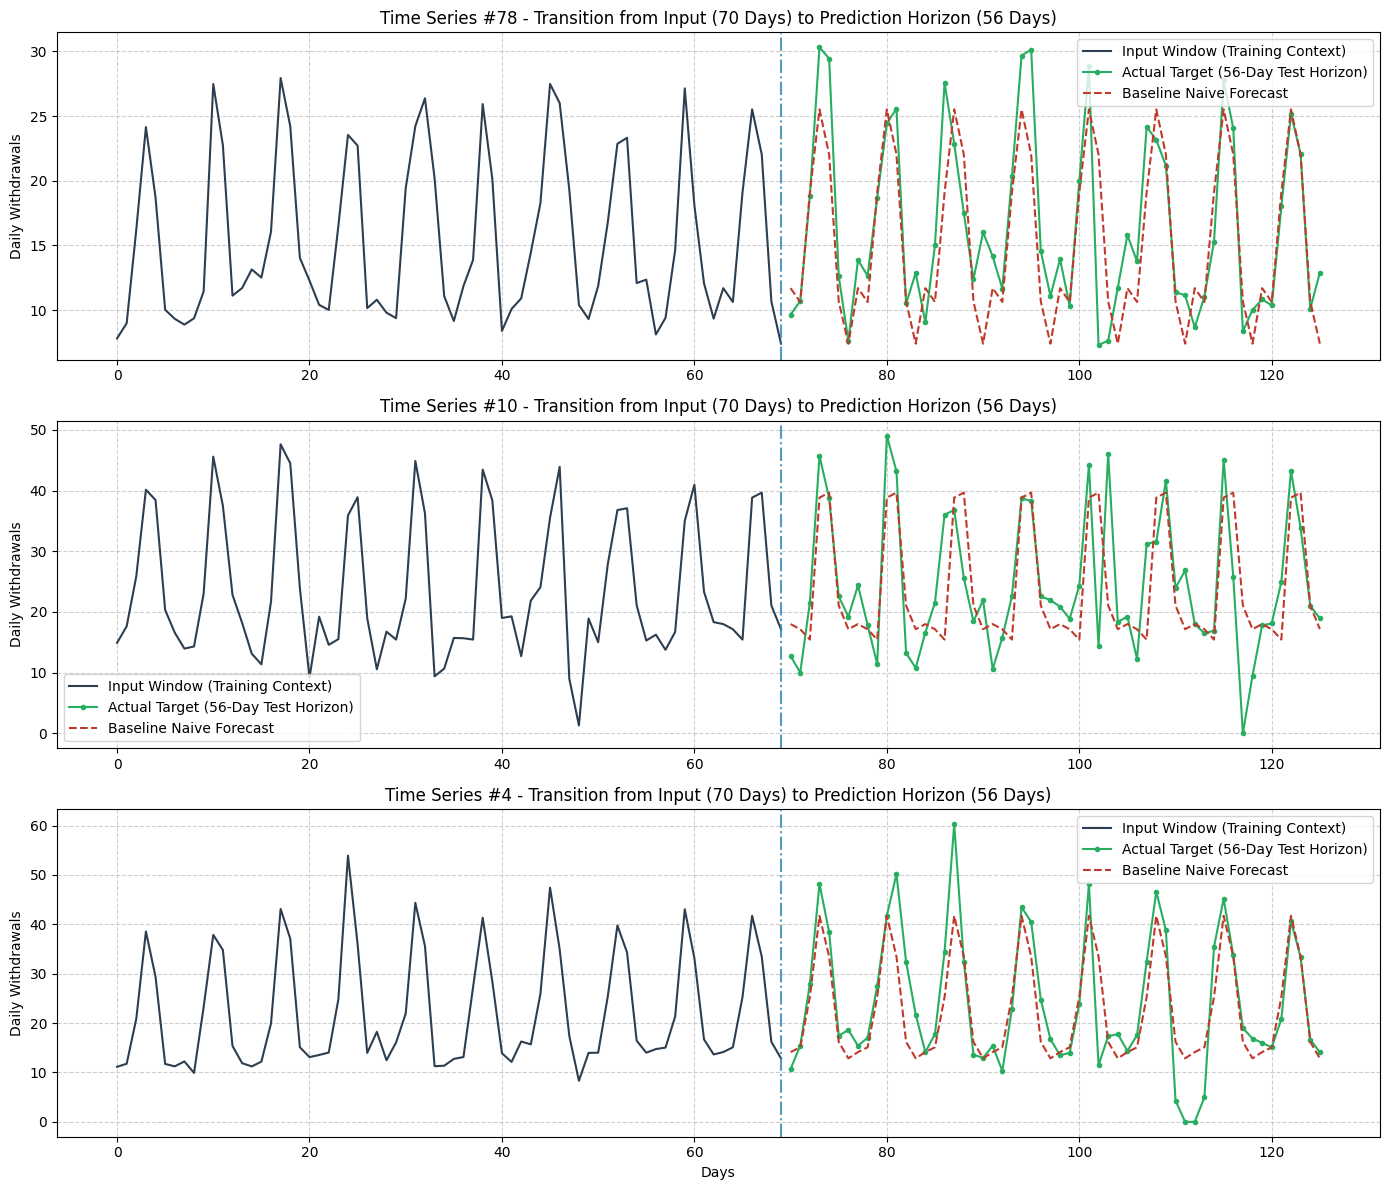

In [10]:
# Choose 3 random time series to plot the preprocessing and "simulated" predictions 
np.random.seed(42)
sample_indices = np.random.choice(data.shape[0], 3, replace=False)

INPUT_SIZE = 70
OUTPUT_SIZE = 56
FREQ = 7

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i, ts_idx in enumerate(sample_indices):
    ts = data[ts_idx]
    
    # Process just like the model
    ts_log = np.log(ts + 1)
    
    # Needs len > 13 for STL, which we have (791)
    stl = STL(ts_log, period=FREQ, seasonal=13).fit()
    trend = stl.trend
    seasonal = stl.seasonal
    remainder = stl.resid
    
    # Ground truth for the last window
    ts_len = len(ts)
    max_idx = ts_len - INPUT_SIZE - OUTPUT_SIZE
    
    # Input window (real)
    in_window_real = ts[max_idx : max_idx + INPUT_SIZE]
    
    # Output window (real)
    out_window_real = ts[max_idx + INPUT_SIZE : max_idx + INPUT_SIZE + OUTPUT_SIZE]
    
    # X axis for plotting
    x_in = np.arange(INPUT_SIZE)
    x_out = np.arange(INPUT_SIZE, INPUT_SIZE + OUTPUT_SIZE)
    
    ax = axes[i]
    
    # Plot real input data
    ax.plot(x_in, in_window_real, label='Input Window (Training Context)', color='#2c3e50', linewidth=1.5)
    
    # Plot real output data
    ax.plot(x_out, out_window_real, label='Actual Target (56-Day Test Horizon)', color='#27ae60', marker='.', markersize=6, linestyle='-', linewidth=1.5)
    
    # Let's create a "Baseline Forecast" (Seasonal Naive) just to show a prediction line
    # Seasonal Naive: Forecast is the value from exactly 'FREQ' steps ago.
    naive_forecast = []
    for step in range(OUTPUT_SIZE):
        # Taking from the end of the input window
        hist_idx = INPUT_SIZE - FREQ + (step % FREQ)
        naive_forecast.append(in_window_real[hist_idx])
        
    ax.plot(x_out, naive_forecast, label='Baseline Naive Forecast', color='#c0392b', linestyle='--', linewidth=1.5)
    
    ax.set_title(f'Time Series #{ts_idx} - Transition from Input (70 Days) to Prediction Horizon (56 Days)', fontsize=12)
    ax.set_ylabel('Daily Withdrawals')
    if i == 2:
        ax.set_xlabel('Days')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()
    
    # Add a vertical line separating input and output
    ax.axvline(x=INPUT_SIZE - 1, color='#2980b9', linestyle='-.', alpha=0.8, label='Prediction Start')

plt.tight_layout()
plt.show()